# Modelo de atraso de entrega — XGBoost e a escolha do threshold

O modelo não devolve "atrasa / não atrasa": devolve uma **probabilidade**. Quem transforma
isso em decisão é o **corte (threshold)**. Este notebook compara quatro versões do mesmo
problema e mostra por que o corte padrão de 0.5 não serve aqui:

| Versão | Modelo | Corte |
|---|---|---|
| **V1** | XGBoost com hiperparâmetros padrão | 0.5 |
| **V2** | XGBoost otimizado com Optuna | 0.5 |
| **V3** | mesmo modelo da V2 | escolhido em previsões out-of-fold com **CV aleatória** |
| **V4** | mesmo modelo da V2 | escolhido em previsões out-of-fold com **CV temporal** |

Roteiro: split temporal → V1 → V2 → por que 0.5 falha → como escolher o corte →
comparação gráfica das versões → estabilidade mês a mês → decisão.

In [1]:
# Recarrega src/ a cada execução: sem isso, editar um módulo com o kernel
# aberto não muda nada até reiniciar (o módulo fica em cache no sys.modules).
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, PercentFormatter
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, cross_val_predict, cross_validate

from src.config import MIN_RECALL, RANDOM_STATE, XGB_TUNED_PARAMS
from src.features import build_dataset
from src.metrics import classification_metrics
from src.modeling import build_xgb_pipeline, compare_baselines, split_xy, temporal_split
from src.plotting import (
    CLASS_COLORS,
    GRID,
    INK,
    INK_2,
    METRIC_COLORS,
    SEQUENTIAL_CMAP,
    SURFACE,
    VERSION_COLORS,
    apply_style,
)
from src.thresholds import choose_threshold, temporal_oof_proba
from src.tuning import tune_xgb

apply_style()
pd.set_option("display.max_columns", None)

/Users/joseeduardodeoliveiralima/projetos/olist-atraso/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = build_dataset()

In [3]:
df.head()

,order_id,order_purchase_timestamp,preco_total,frete_total,n_itens,product_weight_g,payment_installments,payment_value_total,prazo_prometido,estados_diferentes,distancia_km,seller_pedidos_anteriores,seller_taxa_atraso_historica,clima_atraso_7d,clima_atraso_30d,clima_choque,pressao_demanda,dia_semana_compra,mes_compra,mes_sin,mes_cos,dias_para_natal,semana_black_friday,product_category_name,customer_state,seller_state,atrasado
29811,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,134.97,8.49,3,1000.0,NaN,NaN,18,1,565.959812,0,0.0,NaN,NaN,NaN,NaN,3,9,-1.000000,-1.836970e-16,100,0,beleza_saude,SP,PR,1
90509,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,29.90,15.56,1,300.0,1.0,45.46,23,1,708.754247,0,0.0,NaN,NaN,NaN,0.000000,0,10,-0.866025,5.000000e-01,82,0,relogios_presentes,SP,PR,0
27599,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,21.90,17.19,1,400.0,1.0,39.09,34,1,915.912412,0,0.0,NaN,NaN,NaN,6.428571,0,10,-0.866025,5.000000e-01,82,0,esporte_lazer,RS,SP,0
89876,65d1e226dfaeb8cdc42f665422522d14,2016-10-03 21:01:41,21.50,14.11,1,476.0,1.0,35.61,52,1,357.574592,0,0.0,NaN,NaN,NaN,8.571429,0,10,-0.866025,5.000000e-01,82,0,esporte_lazer,RJ,SP,0
95058,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,36.49,17.24,1,767.0,1.0,53.73,56,1,818.146504,0,0.0,NaN,NaN,NaN,9.642857,0,10,-0.866025,5.000000e-01,82,0,esporte_lazer,RS,SP,0


## 1. Split temporal — e o nível de atraso que não para quieto

O modelo em produção sempre prevê o futuro a partir do passado, então o teste são os
últimos 20% dos pedidos no tempo. Um detalhe desse split vai importar muito para o
threshold: **a taxa de atraso muda bastante de um mês para o outro**. Um corte fixo em
probabilidade vai sinalizar muito ou pouco dependendo de quanto a operação está atrasando.

Treino: 2016-09-15 a 2018-05-26 |  77180 pedidos | taxa de atraso 8.8%
Teste: 2018-05-26 a 2018-08-29 |  19296 pedidos | taxa de atraso 5.3%


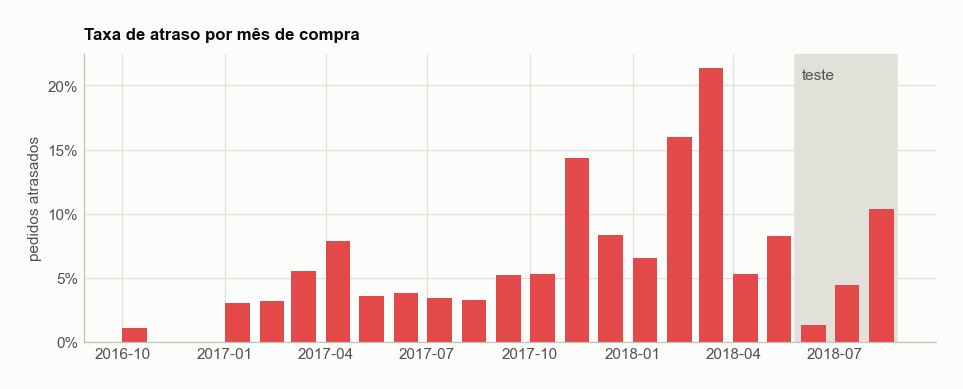

In [4]:
train_df, test_df = temporal_split(df)

X_train, y_train = split_xy(train_df)
X_test, y_test = split_xy(test_df)

for nome, parte in [("Treino", train_df), ("Teste", test_df)]:
    ts = parte["order_purchase_timestamp"]
    print(f"{nome}: {ts.min():%Y-%m-%d} a {ts.max():%Y-%m-%d} | {len(parte):>6} pedidos | taxa de atraso {parte['atrasado'].mean():.1%}")

mensal = df.set_index("order_purchase_timestamp")["atrasado"].resample("MS").agg(["mean", "count"])
mensal = mensal[mensal["count"] >= 100]  # 2016 tem meses com poucas dezenas de pedidos
inicio_teste = test_df["order_purchase_timestamp"].min()

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.axvspan(inicio_teste, mensal.index.max() + pd.Timedelta(days=25), color=GRID, zorder=0)
ax.bar(mensal.index, mensal["mean"], width=22, align="edge", color=CLASS_COLORS[1])
ax.text(inicio_teste + pd.Timedelta(days=6), mensal["mean"].max(), "teste", color=INK_2, va="top")
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylabel("pedidos atrasados")
ax.set_title("Taxa de atraso por mês de compra")
plt.show()

## 2. V1 — XGBoost padrão, corte 0.5

In [5]:
display(compare_baselines(X_train, y_train, X_test, y_test).round(4))

pipeline = build_xgb_pipeline().fit(X_train, y_train)
proba_v1 = pipeline.predict_proba(X_test)[:, 1]
preds = (proba_v1 >= 0.5).astype(int)

print("Modelo: XGBoost padrão (V1)")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_v1):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_v1):.4f}")
print(f"Recall: {recall_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=["no prazo", "atrasado"]))

,ROC-AUC,PR-AUC,Recall (corte 0.5)
Regressão Logística,0.6957,0.1119,0.2262
Árvore de Decisão,0.5942,0.0726,0.1910
KNN,0.5286,0.0554,0.0029


Modelo: XGBoost padrão (V1)
ROC-AUC: 0.7607
PR-AUC: 0.1492
Recall: 0.0069
              precision    recall  f1-score   support

    no prazo       0.95      1.00      0.97     18275
    atrasado       0.23      0.01      0.01      1021

    accuracy                           0.95     19296
   macro avg       0.59      0.50      0.49     19296
weighted avg       0.91      0.95      0.92     19296



### Validação cruzada: aleatória × temporal

A CV estratificada com `shuffle=True` mistura pedidos de todas as épocas: cada fold de
validação fica cercado, no tempo, por pedidos de treino do mesmo período. As features de
clima e calendário viram quase um "identificador de mês", e a métrica sai otimista.
A `TimeSeriesSplit` só valida no futuro de cada fold de treino — é o que acontece em produção.
Essa diferença vai reaparecer na escolha do threshold (seção 5).

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    build_xgb_pipeline(),
    X_train,
    y_train,
    cv=cv,
    scoring=["roc_auc", "average_precision", "recall"],
)

print("Validação cruzada estratificada (10 folds, treino):")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"PR-AUC: {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")
print(f"Recall: {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")

cv_temporal = TimeSeriesSplit(n_splits=5)
cv_temporal_results = cross_validate(
    build_xgb_pipeline(),
    X_train,
    y_train,
    cv=cv_temporal,
    scoring=["roc_auc", "average_precision"],
)

print("\nValidação cruzada temporal (TimeSeriesSplit, 5 folds, treino):")
print(f"ROC-AUC: {cv_temporal_results['test_roc_auc'].mean():.4f} ± {cv_temporal_results['test_roc_auc'].std():.4f}")
print(f"PR-AUC: {cv_temporal_results['test_average_precision'].mean():.4f} ± {cv_temporal_results['test_average_precision'].std():.4f}")

Validação cruzada estratificada (10 folds, treino):
ROC-AUC: 0.8013 ± 0.0095
PR-AUC: 0.3611 ± 0.0173
Recall: 0.1412 ± 0.0107



Validação cruzada temporal (TimeSeriesSplit, 5 folds, treino):
ROC-AUC: 0.6030 ± 0.0219
PR-AUC: 0.1422 ± 0.0774


## 3. V2 — XGBoost otimizado com Optuna, corte 0.5

A busca está em `src/tuning.py` (`tune_xgb`): 30 trials, ROC-AUC médio numa **CV temporal**
(`TimeSeriesSplit`, 5 folds), sampler com semente fixa — a busca (e tudo que depende dela abaixo)
é reproduzível. A CV é temporal pelo motivo da seção anterior: com a CV aleatória, a busca
otimizaria uma métrica inflada e escolheria hiperparâmetros que não generalizam para meses novos
(numa primeira versão desta análise foi exatamente o que aconteceu: a V2 ficou **pior** que a V1 no teste).
O resultado fica fixado em `src/config.py` (`XGB_TUNED_PARAMS`), que é o que o `make train` usa.

In [7]:
study = tune_xgb(X_train, y_train, n_trials=30)

print(f"Melhor ROC-AUC (CV): {study.best_value:.4f}")
print("Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nIguais aos fixados em src/config.py (XGB_TUNED_PARAMS)? {study.best_params == XGB_TUNED_PARAMS}")

best_pipeline = build_xgb_pipeline(study.best_params).fit(X_train, y_train)
proba_v2 = best_pipeline.predict_proba(X_test)[:, 1]
preds = (proba_v2 >= 0.5).astype(int)

print("\nModelo: XGBoost otimizado com Optuna (V2)")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_v2):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_v2):.4f}")
print(f"Recall: {recall_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=["no prazo", "atrasado"]))

Melhor ROC-AUC (CV): 0.6420
Melhores hiperparâmetros:
  n_estimators: 276
  max_depth: 4
  learning_rate: 0.046281728250508816
  subsample: 0.6308643418930251
  colsample_bytree: 0.8549072272510246
  min_child_weight: 6
  reg_lambda: 0.0030507643098015153
  scale_pos_weight: 5.4397767527678

Iguais aos fixados em src/config.py (XGB_TUNED_PARAMS)? True



Modelo: XGBoost otimizado com Optuna (V2)
ROC-AUC: 0.7244
PR-AUC: 0.1031
Recall: 0.0705
              precision    recall  f1-score   support

    no prazo       0.95      0.97      0.96     18275
    atrasado       0.12      0.07      0.09      1021

    accuracy                           0.92     19296
   macro avg       0.53      0.52      0.52     19296
weighted avg       0.91      0.92      0.91     19296



## 4. Por que o corte de 0.5 não serve

"Classificar como atrasado se a probabilidade for ≥ 0.5" só é a decisão certa quando três
coisas valem ao mesmo tempo:

1. **as probabilidades estão calibradas** (entre pedidos com score 0.3, ~30% atrasam de fato);
2. **errar para um lado custa o mesmo que errar para o outro**;
3. o objetivo é **acertar o máximo de pedidos no total** (acurácia).

Nenhuma das três vale aqui:

- **Classe rara.** Só ~8% dos pedidos atrasam. Um modelo calibrado raramente tem motivo para
  passar de 0.5 — mesmo os pedidos mais arriscados costumam ter chance de atraso bem abaixo disso.
  Resultado: quase nada é sinalizado e o recall despenca, **mesmo com um ranking bom**.
- **`scale_pos_weight` descalibra de propósito.** A V2 multiplica o peso dos atrasados no
  treino, o que empurra todos os scores para cima. O mesmo número 0.5 passa a significar outra
  coisa. Ou seja: **0.5 não é um valor neutro — o significado dele depende de como o modelo foi treinado.**
- **Custos assimétricos.** Deixar passar um atraso (cliente insatisfeito, avaliação ruim) não
  custa o mesmo que um alarme falso (um contato proativo desnecessário).

Os histogramas mostram onde cada versão coloca os pedidos de cada classe no teste:

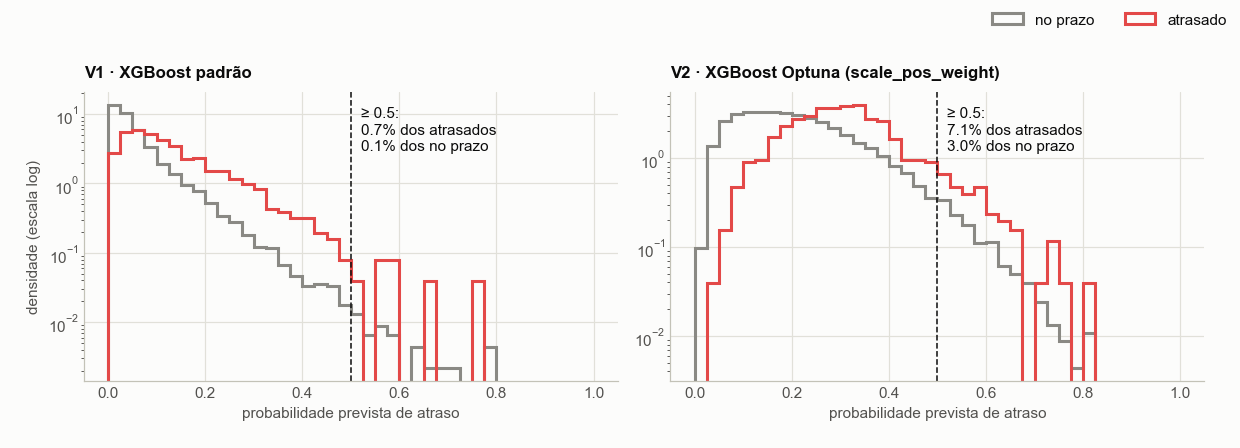

,V1,V2
proba média — no prazo,0.0608,0.2175
proba média — atrasado,0.1315,0.3113
% atrasados com proba ≥ 0.5,0.0069,0.0705
% no prazo com proba ≥ 0.5,0.0013,0.0295
taxa real de atraso no teste,0.0529,0.0529


In [8]:
y_test_arr = y_test.to_numpy()
bins = np.linspace(0, 1, 41)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (_versao, proba, titulo) in zip(
    axes,
    [("V1", proba_v1, "V1 · XGBoost padrão"), ("V2", proba_v2, "V2 · XGBoost Optuna (scale_pos_weight)")],
):
    for classe, rotulo in [(0, "no prazo"), (1, "atrasado")]:
        ax.hist(proba[y_test_arr == classe], bins=bins, density=True, histtype="step",
                linewidth=2, color=CLASS_COLORS[classe], label=rotulo)
    ax.axvline(0.5, color=INK, linestyle="--", linewidth=1)
    acima = proba >= 0.5
    ax.text(0.52, 0.95,
            f"≥ 0.5:\n{acima[y_test_arr == 1].mean():.1%} dos atrasados\n{acima[y_test_arr == 0].mean():.1%} dos no prazo",
            transform=ax.get_xaxis_transform(), va="top", color=INK)
    ax.set_yscale("log")
    ax.set_title(titulo)
    ax.set_xlabel("probabilidade prevista de atraso")
axes[0].set_ylabel("densidade (escala log)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

pd.DataFrame({
    versao: {
        "proba média — no prazo": proba[y_test_arr == 0].mean(),
        "proba média — atrasado": proba[y_test_arr == 1].mean(),
        "% atrasados com proba ≥ 0.5": (proba[y_test_arr == 1] >= 0.5).mean(),
        "% no prazo com proba ≥ 0.5": (proba[y_test_arr == 0] >= 0.5).mean(),
        "taxa real de atraso no teste": y_test_arr.mean(),
    }
    for versao, proba in [("V1", proba_v1), ("V2", proba_v2)]
}).round(4)

**Leitura.**

- **O modelo separa as classes.** Nas duas versões os atrasados recebem, em média, score maior
  que os pedidos no prazo (V1: 0.132 × 0.061; V2: 0.311 × 0.218). O ranking existe.
- **Mas quase ninguém passa de 0.5.** Só 0.7% (V1) e 7.1% (V2) dos atrasados cruzam a linha.
  O problema não é o modelo não enxergar o atraso: é o corte estar num lugar onde os scores quase nunca chegam.
- **A V2 desloca a distribuição inteira para a direita**: a proba média dos pedidos no prazo
  vai de 0.061 para 0.218 (3.6×). É o `scale_pos_weight` ≈ 5.4 escolhido pelo Optuna. O "0.5" da V1 e o
  "0.5" da V2 não são a mesma régua.

## 5. Como escolher o corte

### O critério

O modelo vai ser usado para **agir antes do atraso** (avisar o cliente, priorizar a
expedição, acionar o vendedor). Perder um atraso é o erro caro, então o critério é:

> **entre os cortes que pegam pelo menos `MIN_RECALL` (50%) dos atrasos, usar o mais alto** —
> ou seja, o de maior precisão, o que gera menos alarmes falsos para esse nível de cobertura.

É o que `choose_threshold` em `src/thresholds.py` implementa. Outros critérios válidos seriam
maximizar o F1 ou minimizar um custo explícito (`custo_FN × FN + custo_FP × FP`) — trocar o
critério não muda nada do raciocínio abaixo, só o ponto escolhido na curva.

### Onde escolher: nunca no teste

Escolher o corte olhando o teste é ajustar um hiperparâmetro no conjunto de avaliação — o
número final sairia otimista. O corte é escolhido em **previsões out-of-fold (OOF) do treino**:
cada pedido do treino recebe a probabilidade de um modelo que não o viu.

### Qual OOF: aleatório (V3) × temporal (V4)

- **V3** usa a CV aleatória (`StratifiedKFold`, 10 folds) — era o que o notebook fazia antes.
- **V4** usa `TimeSeriesSplit` (`temporal_oof_proba` em `src/thresholds.py`): cada bloco do treino é previsto por um modelo treinado só com o
  passado dele, exatamente a situação de produção. O primeiro bloco fica sem previsão (não há
  passado) e é descartado.

Se o OOF aleatório for otimista (como a CV aleatória foi na seção 2), os scores dos atrasados
nele ficam "altos demais", o corte escolhido fica alto demais, e o recall prometido não se
repete no futuro.

In [9]:
# V3: OOF com CV aleatória (o `cv` de 10 folds da seção 2)
oof_aleatorio = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
y_oof_aleatorio = y_train.to_numpy()
threshold_v3 = choose_threshold(y_oof_aleatorio, oof_aleatorio)

# V4: OOF com CV temporal
oof_temp, y_oof_temp = temporal_oof_proba(best_pipeline, X_train, y_train)
threshold_v4 = choose_threshold(y_oof_temp, oof_temp)

promessa = pd.DataFrame({
    "V3 · OOF aleatório": {
        "threshold": threshold_v3,
        "recall no OOF (prometido)": recall_score(y_oof_aleatorio, oof_aleatorio >= threshold_v3),
        "recall no teste (entregue)": recall_score(y_test, proba_v2 >= threshold_v3),
        "precisão no OOF": precision_score(y_oof_aleatorio, oof_aleatorio >= threshold_v3),
        "precisão no teste": precision_score(y_test, proba_v2 >= threshold_v3),
        "ROC-AUC do OOF": roc_auc_score(y_oof_aleatorio, oof_aleatorio),
    },
    "V4 · OOF temporal": {
        "threshold": threshold_v4,
        "recall no OOF (prometido)": recall_score(y_oof_temp, oof_temp >= threshold_v4),
        "recall no teste (entregue)": recall_score(y_test, proba_v2 >= threshold_v4),
        "precisão no OOF": precision_score(y_oof_temp, oof_temp >= threshold_v4),
        "precisão no teste": precision_score(y_test, proba_v2 >= threshold_v4),
        "ROC-AUC do OOF": roc_auc_score(y_oof_temp, oof_temp),
    },
}).round(4)
promessa

,V3 · OOF aleatório,V4 · OOF temporal
threshold,0.5040,0.2762
recall no OOF (prometido),0.5000,0.5001
recall no teste (entregue),0.0656,0.5975
precisão no OOF,0.3180,0.1505
precisão no teste,0.1157,0.1066
ROC-AUC do OOF,0.7977,0.6306


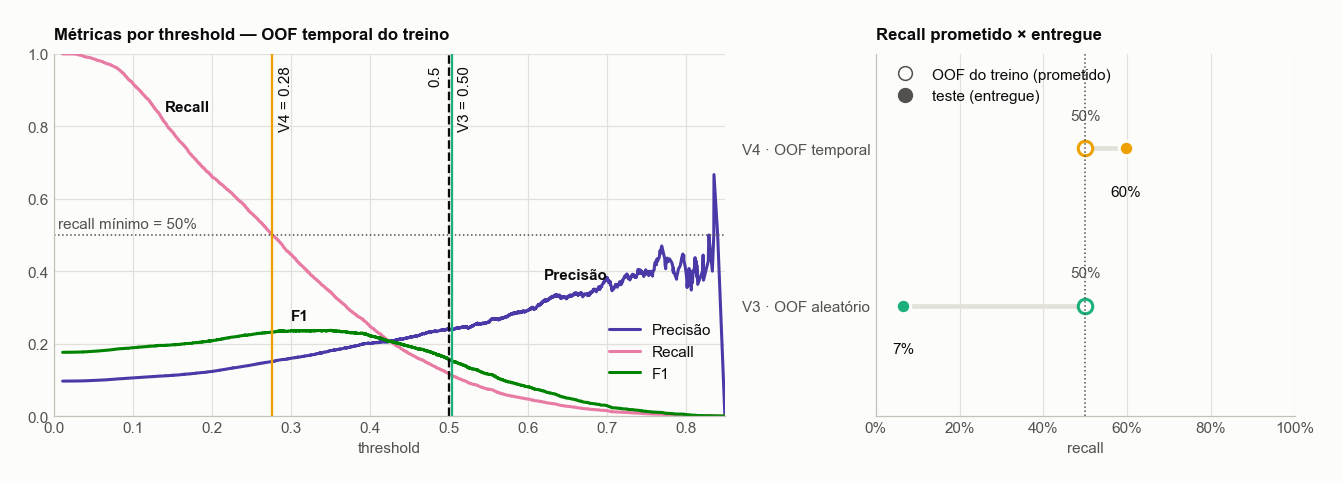

In [10]:
fig, (ax_curva, ax_promessa) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})

# Esquerda: precisão, recall e F1 em função do corte, no OOF temporal (onde a V4 escolhe)
precisao, recall, cortes = precision_recall_curve(y_oof_temp, oof_temp)
precisao, recall = precisao[:-1], recall[:-1]
f1 = np.divide(2 * precisao * recall, precisao + recall, out=np.zeros_like(recall), where=(precisao + recall) > 0)

for nome, valores in [("Precisão", precisao), ("Recall", recall), ("F1", f1)]:
    ax_curva.plot(cortes, valores, color=METRIC_COLORS[nome], label=nome)
# Rótulo direto de cada curva num trecho onde elas não se cruzam
for nome, valores, x_rotulo, dy in [("Recall", recall, 0.14, 0.03), ("Precisão", precisao, 0.62, 0.06), ("F1", f1, 0.30, 0.03)]:
    y_rotulo = np.interp(x_rotulo, cortes, valores)
    ax_curva.text(x_rotulo, y_rotulo + dy, nome, color=INK, fontweight="bold")

ax_curva.axhline(MIN_RECALL, color=INK_2, linestyle=":", linewidth=1)
ax_curva.text(0.005, MIN_RECALL + 0.02, f"recall mínimo = {MIN_RECALL:.0%}", color=INK_2)
for rotulo, corte, cor, estilo in [
    ("0.5", 0.5, INK, "--"),
    (f"V3 = {threshold_v3:.2f}", threshold_v3, VERSION_COLORS["V3"], "-"),
    (f"V4 = {threshold_v4:.2f}", threshold_v4, VERSION_COLORS["V4"], "-"),
]:
    ax_curva.axvline(corte, color=cor, linestyle=estilo, linewidth=1.5)
    # o rótulo do 0.5 vai à esquerda da linha: o corte da V3 pode cair logo ao lado
    esquerda = rotulo == "0.5"
    ax_curva.text(corte - 0.008 if esquerda else corte + 0.008, 0.97, rotulo, color=INK, va="top",
                  rotation=90, ha="right" if esquerda else "left")
ax_curva.set_xlim(0, 0.85)
ax_curva.set_ylim(0, 1)
ax_curva.set_xlabel("threshold")
ax_curva.set_title("Métricas por threshold — OOF temporal do treino")
ax_curva.legend(loc="lower right", bbox_to_anchor=(1, 0.06))

# Direita: recall prometido (OOF) × entregue (teste) para os dois cortes
for i, versao in enumerate(["V3", "V4"]):
    linha = promessa.iloc[:, i]
    prometido, entregue = linha["recall no OOF (prometido)"], linha["recall no teste (entregue)"]
    ax_promessa.plot([prometido, entregue], [i, i], color=GRID, linewidth=3, zorder=1)
    ax_promessa.scatter(prometido, i, s=90, facecolor=SURFACE, edgecolor=VERSION_COLORS[versao], linewidth=2, zorder=2)
    ax_promessa.scatter(entregue, i, s=90, color=VERSION_COLORS[versao], edgecolor=SURFACE, linewidth=2, zorder=3)
    ax_promessa.text(prometido, i + 0.18, f"{prometido:.0%}", ha="center", color=INK_2)
    ax_promessa.text(entregue, i - 0.3, f"{entregue:.0%}", ha="center", color=INK)
ax_promessa.axvline(MIN_RECALL, color=INK_2, linestyle=":", linewidth=1)
ax_promessa.set_yticks([0, 1], ["V3 · OOF aleatório", "V4 · OOF temporal"])
ax_promessa.set_ylim(-0.7, 1.6)
ax_promessa.set_xlim(0, 1)
ax_promessa.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax_promessa.set_xlabel("recall")
ax_promessa.set_title("Recall prometido × entregue")
ax_promessa.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", markerfacecolor=SURFACE, markeredgecolor=INK_2, markersize=9, label="OOF do treino (prometido)"),
        Line2D([], [], marker="o", linestyle="", color=INK_2, markersize=9, label="teste (entregue)"),
    ],
    loc="upper left",
)
ax_promessa.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

**Leitura.**

- **Onde fica o corte certo.** Na curva da esquerda, o recall cai rápido: em 0.5 ele já está
  perto de 11%. Para garantir 50% de recall no OOF temporal, o corte precisa descer para **0.28**,
  que também fica perto do pico do F1. Os dois critérios concordam aqui.
- **O OOF aleatório promete mais do que entrega.** O ROC-AUC dele é 0.798, contra 0.631 no
  temporal: é otimista pelo mesmo motivo da CV aleatória da seção 2. Os atrasados recebem scores
  altos demais, o corte sai alto demais (0.50), e **os 50% de recall prometidos viram 7% no teste**.
- **O OOF temporal erra para o outro lado, e pouco.** Ele prometeu 50% e entregou **60%**. Os modelos
  dos folds temporais treinam com menos histórico (o primeiro, com só 1/6 do treino) e
  ranqueiam pior que o modelo final. Por isso o corte sai levemente conservador.
- Nenhum dos dois OOF acerta a promessa exatamente. Só que o temporal erra a favor do critério
  de negócio (perder menos atrasos), e o viés dele vem de uma fonte que existe em produção.
  O viés do aleatório vem de um vazamento que não existe.

## 6. Comparação das quatro versões

V2, V3 e V4 são **o mesmo modelo** — mudam só o corte. Por isso têm exatamente o mesmo
ROC-AUC e PR-AUC: essas métricas avaliam o **ranking** (todos os cortes de uma vez) e não
dependem do threshold. O que o threshold muda é o **ponto de operação**: quantos pedidos
são sinalizados, e com isso a troca entre precisão e recall.

In [11]:
VERSOES = {
    "V1": ("XGBoost padrão", proba_v1, 0.5),
    "V2": ("XGBoost Optuna", proba_v2, 0.5),
    "V3": ("Optuna + corte OOF aleatório", proba_v2, threshold_v3),
    "V4": ("Optuna + corte OOF temporal", proba_v2, threshold_v4),
}
COLUNAS = {
    "threshold": "threshold", "precision": "Precisão", "recall": "Recall", "f1": "F1",
    "roc_auc": "ROC-AUC", "pr_auc": "PR-AUC", "flagged_rate": "% sinalizados",
    "tp": "VP", "fp": "FP", "fn": "FN", "tn": "VN",
}

comparacao = (
    pd.DataFrame({versao: classification_metrics(y_test, proba, corte) for versao, (_, proba, corte) in VERSOES.items()})
    .T[list(COLUNAS)]
    .rename(columns=COLUNAS)
)
comparacao.insert(0, "modelo", [modelo for modelo, _, _ in VERSOES.values()])
comparacao.round(4)

,modelo,threshold,Precisão,Recall,F1,ROC-AUC,PR-AUC,% sinalizados,VP,FP,FN,VN
V1,XGBoost padrão,0.5000,0.2333,0.0069,0.0133,0.7607,0.1492,0.0016,7.0,23.0,1014.0,18252.0
V2,XGBoost Optuna,0.5000,0.1176,0.0705,0.0882,0.7244,0.1031,0.0317,72.0,540.0,949.0,17735.0
V3,Optuna + corte OOF aleatório,0.5040,0.1157,0.0656,0.0838,0.7244,0.1031,0.0300,67.0,512.0,954.0,17763.0
V4,Optuna + corte OOF temporal,0.2762,0.1066,0.5975,0.1809,0.7244,0.1031,0.2966,610.0,5114.0,411.0,13161.0


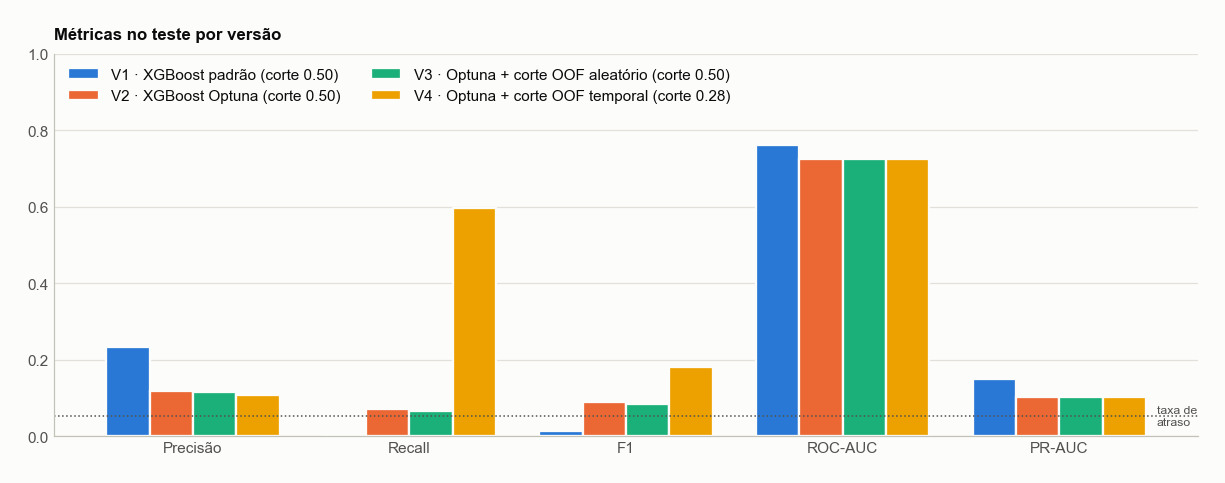

In [12]:
METRICAS = ["Precisão", "Recall", "F1", "ROC-AUC", "PR-AUC"]
largura = 0.2
x = np.arange(len(METRICAS))

fig, ax = plt.subplots(figsize=(11, 4.2))
for i, (versao, (modelo, _, corte)) in enumerate(VERSOES.items()):
    ax.bar(x + (i - 1.5) * largura, comparacao.loc[versao, METRICAS].astype(float), width=largura,
           color=VERSION_COLORS[versao], edgecolor=SURFACE, linewidth=1.5,
           label=f"{versao} · {modelo} (corte {corte:.2f})")
ax.axhline(y_test.mean(), color=INK_2, linestyle=":", linewidth=1)
ax.text(x[-1] + 0.45, y_test.mean(), "taxa de\natraso", color=INK_2, va="center", fontsize=8)
ax.set_xticks(x, METRICAS)
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
ax.set_title("Métricas no teste por versão")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

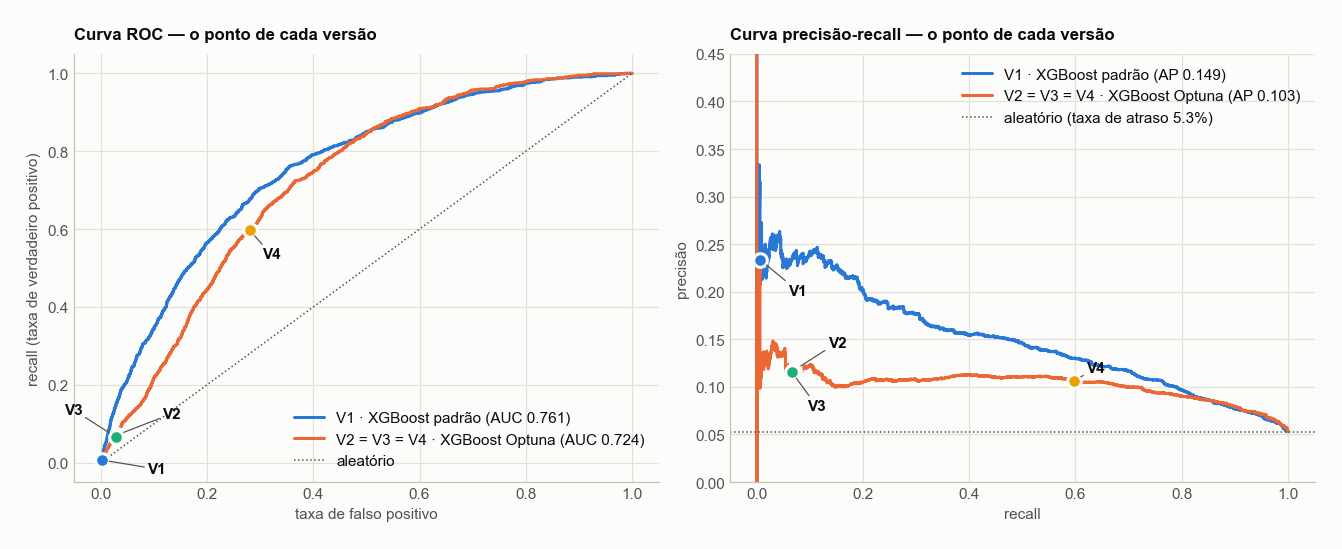

In [13]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.8))

for versao, proba, rotulo in [("V1", proba_v1, "V1 · XGBoost padrão"), ("V2", proba_v2, "V2 = V3 = V4 · XGBoost Optuna")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, color=VERSION_COLORS[versao], label=f"{rotulo} (AUC {roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(rec, prec, color=VERSION_COLORS[versao], label=f"{rotulo} (AP {average_precision_score(y_test, proba):.3f})")

ax_roc.plot([0, 1], [0, 1], color=INK_2, linestyle=":", linewidth=1, label="aleatório")
ax_pr.axhline(y_test.mean(), color=INK_2, linestyle=":", linewidth=1, label=f"aleatório (taxa de atraso {y_test.mean():.1%})")

# Onde cada versão opera em cima da curva
# (ROC, PR): deslocamento do rótulo em pontos — V1 e V2 ficam quase no mesmo lugar
deslocamento = {
    "V1": ((30, -6), (18, -20)),
    "V2": ((30, 14), (22, 18)),
    "V3": ((-34, 18), (10, -22)),
    "V4": ((8, -16), (8, 8)),
}
for versao in VERSOES:
    linha = comparacao.loc[versao]
    fpr_ponto = linha["FP"] / (linha["FP"] + linha["VN"])
    pontos = [(ax_roc, (fpr_ponto, linha["Recall"])), (ax_pr, (linha["Recall"], linha["Precisão"]))]
    for (ax, (px, py)), offset in zip(pontos, deslocamento[versao]):
        ax.scatter(px, py, s=80, color=VERSION_COLORS[versao], edgecolor=SURFACE, linewidth=2, zorder=5)
        ax.annotate(versao, (px, py), xytext=offset, textcoords="offset points", color=INK,
                    fontweight="bold", va="center", zorder=6,
                    arrowprops=dict(arrowstyle="-", color=INK_2, linewidth=0.8, shrinkA=0, shrinkB=5))

ax_roc.set_xlabel("taxa de falso positivo")
ax_roc.set_ylabel("recall (taxa de verdadeiro positivo)")
ax_roc.set_title("Curva ROC — o ponto de cada versão")
ax_roc.legend(loc="lower right")
ax_pr.set_xlabel("recall")
ax_pr.set_ylabel("precisão")
ax_pr.set_title("Curva precisão-recall — o ponto de cada versão")
ax_pr.set_ylim(0, 0.45)  # corta o trecho ruidoso de recall ≈ 0 (poucos pedidos)
ax_pr.legend(loc="upper right")
plt.tight_layout()
plt.show()

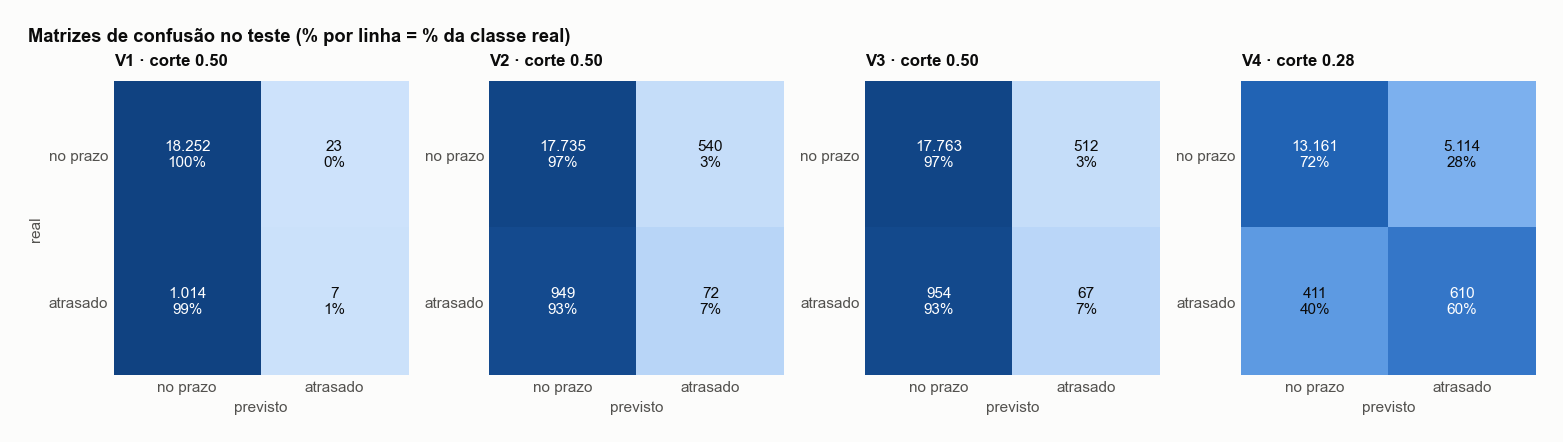

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (versao, (_, proba, corte)) in zip(axes, VERSOES.items()):
    matriz = confusion_matrix(y_test, (proba >= corte).astype(int))
    por_linha = matriz / matriz.sum(axis=1, keepdims=True)
    ax.imshow(por_linha, cmap=SEQUENTIAL_CMAP, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matriz[i, j]:,}\n{por_linha[i, j]:.0%}".replace(",", "."), ha="center", va="center",
                    color="white" if por_linha[i, j] > 0.55 else INK)
    ax.set_xticks([0, 1], ["no prazo", "atrasado"])
    ax.set_yticks([0, 1], ["no prazo", "atrasado"])
    ax.set_xlabel("previsto")
    ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.set_title(f"{versao} · corte {corte:.2f}", color=INK)
axes[0].set_ylabel("real")
fig.suptitle("Matrizes de confusão no teste (% por linha = % da classe real)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

**Leitura.**

- **V1 e V2 (corte 0.5) não funcionam como classificadores.** Sinalizam 0.2% e 3.2% dos pedidos
  e pegam 7 e 72 dos 1.021 atrasos. A acurácia de 92–95% é a de um modelo que responde
  "no prazo" para todo pedido (94.7%).
- **O Optuna não melhorou o ranking no teste** (ROC-AUC 0.761 → 0.724; PR-AUC 0.149 → 0.103),
  embora tenha melhorado a CV temporal do treino (0.603 → 0.642). Ver a conclusão.
- **V2, V3 e V4 são pontos da mesma curva.** O corte só escolhe onde parar. Descer de 0.5
  para 0.28 leva o recall de 7% para 60%, e a precisão quase não muda (11.8% → 10.7%).
- **A precisão de 10.7% tem que ser comparada com a taxa de atraso do teste (5.3%).** Um pedido
  sinalizado pela V4 tem ~2× a chance de atrasar de um pedido qualquer. O F1 sobe de 0.09 (V2)
  para 0.18 (V4).
- **O custo da V4** é sinalizar **30% dos pedidos** (5.724 no teste) para encontrar 610 atrasos:
  ~8 alarmes falsos por atraso encontrado. Se a ação for barata (um aviso automático ao
  cliente), a troca vale. Se for cara (intervenção manual), `MIN_RECALL` deve baixar.

## 7. Estabilidade mês a mês

O corte é fixo, mas a taxa de atraso não é (seção 1). Aqui cada versão é avaliada
separadamente em cada mês do teste. Maio/2018 fica de fora: só os últimos dias do mês caem
no teste e quase não há atrasos nele.

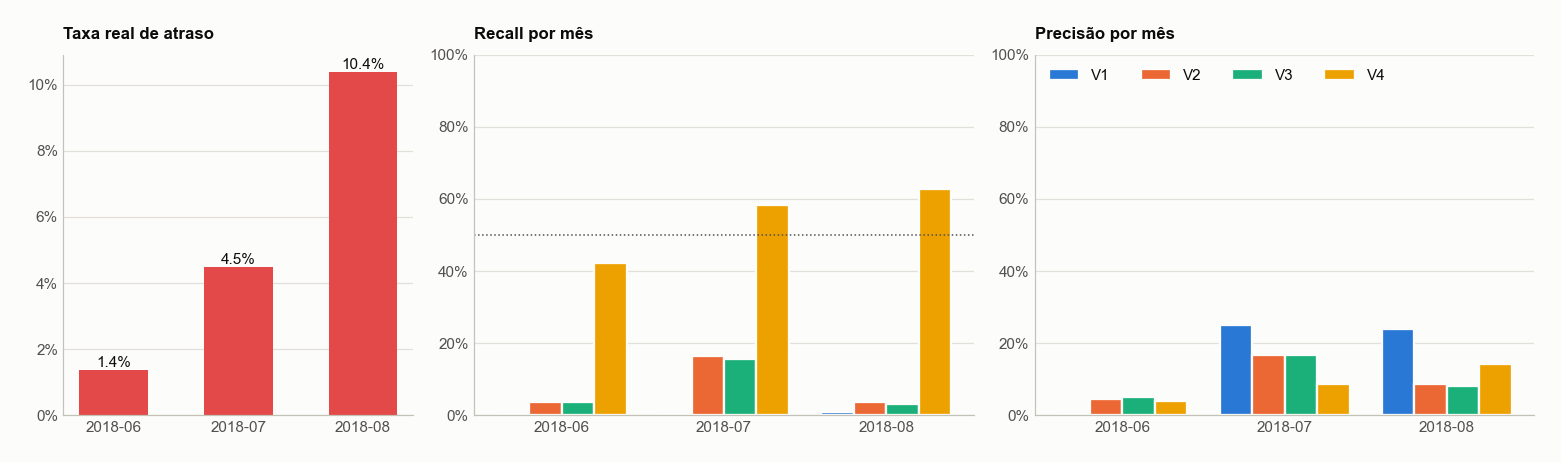

% sinalizados                      Recall                       \
versão             V1     V2     V3     V4     V1     V2     V3     V4   
mês                                                                      
2018-06         0.000  0.011  0.010  0.150  0.000  0.036  0.036  0.422   
2018-07         0.001  0.044  0.042  0.307  0.007  0.163  0.156  0.583   
2018-08         0.003  0.043  0.041  0.460  0.008  0.036  0.032  0.627   

        Precisão                       
versão        V1     V2     V3     V4  
mês                                    
2018-06    0.000  0.046  0.050  0.038  
2018-07    0.250  0.166  0.167  0.085  
2018-08    0.238  0.087  0.080  0.142

In [15]:
mes_teste = test_df["order_purchase_timestamp"].dt.to_period("M").astype(str).to_numpy()
linhas = []
for versao, (_, proba, corte) in VERSOES.items():
    pred = proba >= corte
    for mes in np.unique(mes_teste):
        no_mes = mes_teste == mes
        if no_mes.sum() < 1000:
            continue
        linhas.append({
            "versão": versao,
            "mês": mes,
            "pedidos": no_mes.sum(),
            "taxa de atraso": y_test_arr[no_mes].mean(),
            "% sinalizados": pred[no_mes].mean(),
            "Recall": recall_score(y_test_arr[no_mes], pred[no_mes]),
            "Precisão": precision_score(y_test_arr[no_mes], pred[no_mes], zero_division=0),
            "ROC-AUC": roc_auc_score(y_test_arr[no_mes], proba[no_mes]),
        })
por_mes = pd.DataFrame(linhas)
meses = sorted(por_mes["mês"].unique())
x = np.arange(len(meses))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw={"width_ratios": [0.7, 1, 1]})
taxa = por_mes.drop_duplicates("mês").set_index("mês").loc[meses, "taxa de atraso"]
axes[0].bar(x, taxa, width=0.55, color=CLASS_COLORS[1])
for xi, valor in zip(x, taxa):
    axes[0].text(xi, valor, f"{valor:.1%}", ha="center", va="bottom", color=INK)
axes[0].set_title("Taxa real de atraso")

for ax, metrica in zip(axes[1:], ["Recall", "Precisão"]):
    for i, versao in enumerate(VERSOES):
        valores = por_mes[por_mes["versão"] == versao].set_index("mês").loc[meses, metrica]
        ax.bar(x + (i - 1.5) * 0.2, valores, width=0.2, color=VERSION_COLORS[versao],
               edgecolor=SURFACE, linewidth=1.5, label=versao)
    ax.set_title(f"{metrica} por mês")
    ax.set_ylim(0, 1)

axes[1].axhline(MIN_RECALL, color=INK_2, linestyle=":", linewidth=1)
axes[2].legend(loc="upper left", ncol=4)
for ax in axes:
    ax.set_xticks(x, meses)
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
plt.tight_layout()
plt.show()

por_mes.pivot(index="mês", columns="versão", values=["% sinalizados", "Recall", "Precisão"]).round(3)

**Leitura.** O corte é fixo, mas o comportamento dele muda com o mês:

- Com a mesma régua, a V4 sinaliza **15% dos pedidos em junho e 46% em agosto**. O score
  acompanha o clima da operação (features `clima_*` e de calendário), o que é bom, mas o volume
  de alarmes oscila junto.
- O recall da V4 vai de 42% (junho, taxa de atraso de 1.4%) a 63% (agosto, 10.4%), e a precisão
  vai de 4% a 14%. Em mês calmo, o mesmo corte gera muito alarme falso para poucos atrasos.
- Com corte 0.5, nenhuma versão passa de 17% de recall em nenhum mês.

Um corte único é um compromisso médio entre os meses. Se o volume de alarmes precisar ser
estável (ex.: uma equipe com capacidade fixa de atendimento), a alternativa é sinalizar um
**percentual fixo de pedidos por período** (os top-k pelo score) em vez de usar um corte fixo
em probabilidade, e, nos dois casos, acompanhar o threshold mês a mês.

## 8. Conclusão

1. **O recall baixo vinha do corte, não do modelo.** O ranking é razoável (ROC-AUC 0.72–0.76;
   PR-AUC 0.10–0.15, 2–3× a taxa de atraso do teste). Com corte 0.5, quase todos os pedidos eram
   classificados como "no prazo".
2. **0.5 não é um valor neutro.** Com classe rara ele fica acima de quase todos os scores, e com
   `scale_pos_weight` o significado dele muda a cada treino. O threshold é uma decisão de negócio
   e tem que ser escolhido explicitamente.
3. **O corte é escolhido no OOF temporal, nunca no teste nem no OOF aleatório.** O OOF
   aleatório prometeu 50% de recall e entregou 7%; o temporal prometeu 50% e entregou 60%.
4. **Versão escolhida: V4**: XGBoost (Optuna, CV temporal) com corte 0.28. Recall de 60%,
   precisão de 10.7% (2× a taxa de atraso), 30% dos pedidos sinalizados.
5. **Features point-in-time importam.** A taxa de atraso do vendedor contava pedidos ainda em
   trânsito na data da compra. Corrigida, a V1 subiu de 0.748 para 0.761 de ROC-AUC no teste:
   o vazamento não só inflava a validação como piorava a generalização.
6. **Em aberto, e o ponto mais importante: o tuning não se transferiu para o futuro.** O Optuna
   com CV temporal melhorou a validação (0.603 → 0.642), mas no teste o XGBoost padrão ranqueia
   melhor (0.761 contra 0.724). Uma primeira busca com CV aleatória também ficou abaixo (0.742).
   Com dados não estacionários, os folds do treino premiam hiperparâmetros ajustados a regimes
   específicos (a crise de fev–mar/2018, por exemplo). Como o teste já foi usado para observar
   isso, trocar agora para os parâmetros padrão seria escolher olhando o teste. O próximo passo
   honesto é um split treino/validação/teste temporal (ou uma janela de dados nova) para decidir.
7. **Também em aberto:** calibrar as probabilidades (`CalibratedClassifierCV`) para o score ser
   legível como chance de atraso; avaliar corte por percentual (top-k por período) se a
   capacidade de ação for fixa.

O threshold é salvo junto com o pipeline num `ModelArtifact` (`make train`), então quem carrega o
modelo não tem como usar o corte errado:

In [16]:
print(f"Threshold escolhido (V4, OOF temporal): {threshold_v4:.4f}")
print("O artefato de produção (pipeline + threshold) é gerado por `make train`,")
print("que refaz exatamente a V4 com XGB_TUNED_PARAMS e salva data/processed/model.joblib.")

Threshold escolhido (V4, OOF temporal): 0.2762
O artefato de produção (pipeline + threshold) é gerado por `make train`,
que refaz exatamente a V4 com XGB_TUNED_PARAMS e salva data/processed/model.joblib.
